## Loading the Dataset

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt
import os
df = pd.read_csv("../dataset/cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Data Cleaning and preprocessing

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [3]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df['age'] = (df['age'] / 365).round().astype('int')

#

In [5]:
import pandas as pd
import numpy as np


print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nMissing value % per column:")
print((df.isnull().mean() * 100).round(2))

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (70000, 13)

Columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:
id               int64
age              int32
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

First 5 rows:
   id  age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0   50       2     168    62.0    110     80            1     1      0   
1   1   55       1     156    85.0    140     90            3     1      0   
2   2   52       1     165    64.0    130     70            3     1      0   
3   3   48       2     169    82.0    150    100            1     1      0   
4   4   48       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0      

In [6]:
num_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

outlier_info = []
outlier_values = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # identify outliers
    mask = (df[col] < lower) | (df[col] > upper)
    outliers = df.loc[mask, col]

    outlier_info.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": len(outliers),
        "percent": len(outliers) / len(df) * 100
    })

    # store actual values
    outlier_values[col] = outliers.sort_values()

# Summary table
outlier_df = pd.DataFrame(outlier_info)
print(outlier_df)

   column    min      max  lower_bound  upper_bound  outliers   percent
0     age   30.0     65.0         33.0         73.0         4  0.005714
1  height   55.0    250.0        142.5        186.5       519  0.741429
2  weight   10.0    200.0         39.5        107.5      1819  2.598571
3   ap_hi -150.0  16020.0         90.0        170.0      1435  2.050000
4   ap_lo  -70.0  11000.0         65.0        105.0      4632  6.617143


In [7]:
num_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # get outliers
    outliers = df.loc[(df[col] < lower) | (df[col] > upper), col]

    # convert to clean Python ints
    unique_vals = sorted(set(int(x) for x in outliers))

    print(f"\n===== {col.upper()} OUTLIERS =====")
    print(f"Min: {df[col].min()} | Max: {df[col].max()}")
    print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
    print(f"Count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

    # show first and last few values
    print("Smallest:", unique_vals[:10])
    print("Largest:", unique_vals[-10:])


===== AGE OUTLIERS =====
Min: 30 | Max: 65
Lower bound: 33.00 | Upper bound: 73.00
Count: 4 (0.01%)
Smallest: [30]
Largest: [30]

===== HEIGHT OUTLIERS =====
Min: 55 | Max: 250
Lower bound: 142.50 | Upper bound: 186.50
Count: 519 (0.74%)
Smallest: [55, 57, 59, 60, 64, 65, 66, 67, 68, 70]
Largest: [192, 193, 194, 195, 196, 197, 198, 200, 207, 250]

===== WEIGHT OUTLIERS =====
Min: 10.0 | Max: 200.0
Lower bound: 39.50 | Upper bound: 107.50
Count: 1819 (2.60%)
Smallest: [10, 11, 21, 22, 23, 28, 29, 30, 31, 32]
Largest: [170, 171, 172, 175, 177, 178, 180, 181, 183, 200]

===== AP_HI OUTLIERS =====
Min: -150 | Max: 16020
Lower bound: 90.00 | Upper bound: 170.00
Count: 1435 (2.05%)
Smallest: [-150, -140, -120, -115, -100, 1, 7, 10, 11, 12]
Largest: [1409, 1420, 1500, 1620, 2000, 11020, 11500, 13010, 14020, 16020]

===== AP_LO OUTLIERS =====
Min: -70 | Max: 11000
Lower bound: 65.00 | Upper bound: 105.00
Count: 4632 (6.62%)
Smallest: [-70, 0, 1, 6, 7, 8, 9, 10, 15, 20]
Largest: [8079, 8099, 8

In [8]:
df_clean = df.copy()

initial_rows = len(df_clean)


# Apply filters
df_clean = df_clean[
    # AGE: dataset uses adults; <30 is rare in this dataset, >100 unlikely → remove unrealistic entries
    (df_clean["age"].between(30, 100)) &

    # HEIGHT (cm):
    # <120 cm → implausible for adults (likely data entry error)
    # >220 cm → extremely rare → likely incorrect
    (df_clean["height"].between(120, 220)) &

    # WEIGHT (kg):
    # <30 kg → not realistic for adults
    # >200 kg → possible but very rare; beyond this likely noise in this dataset
    (df_clean["weight"].between(30, 200)) &

    # SYSTOLIC BP (ap_hi):
    # <70 → physiologically implausible (would indicate severe shock)
    # >250 → possible in crisis but values like 1000+ indicate corrupted data
    (df_clean["ap_hi"].between(70, 250)) &

    # DIASTOLIC BP (ap_lo):
    # <40 → implausible (critical hypotension)
    # >150 → extremely rare; higher values in this dataset are typically errors (e.g., 10000)
    (df_clean["ap_lo"].between(40, 150)) &

    # PHYSIOLOGICAL CONSTRAINT:
    # systolic pressure must always be ≥ diastolic
    # violation indicates swapped or corrupted values
    (df_clean["ap_hi"] >= df_clean["ap_lo"])
]

# Stats
final_rows = len(df_clean)
removed_rows = initial_rows - final_rows
remaining_pct = (final_rows / initial_rows) * 100

print(f"Initial rows: {initial_rows}")
print(f"Remaining rows: {final_rows}")
print(f"Removed rows: {removed_rows}")
print(f"Remaining %: {remaining_pct:.2f}%")

df = df_clean

Initial rows: 70000
Remaining rows: 68612
Removed rows: 1388
Remaining %: 98.02%


## EDA

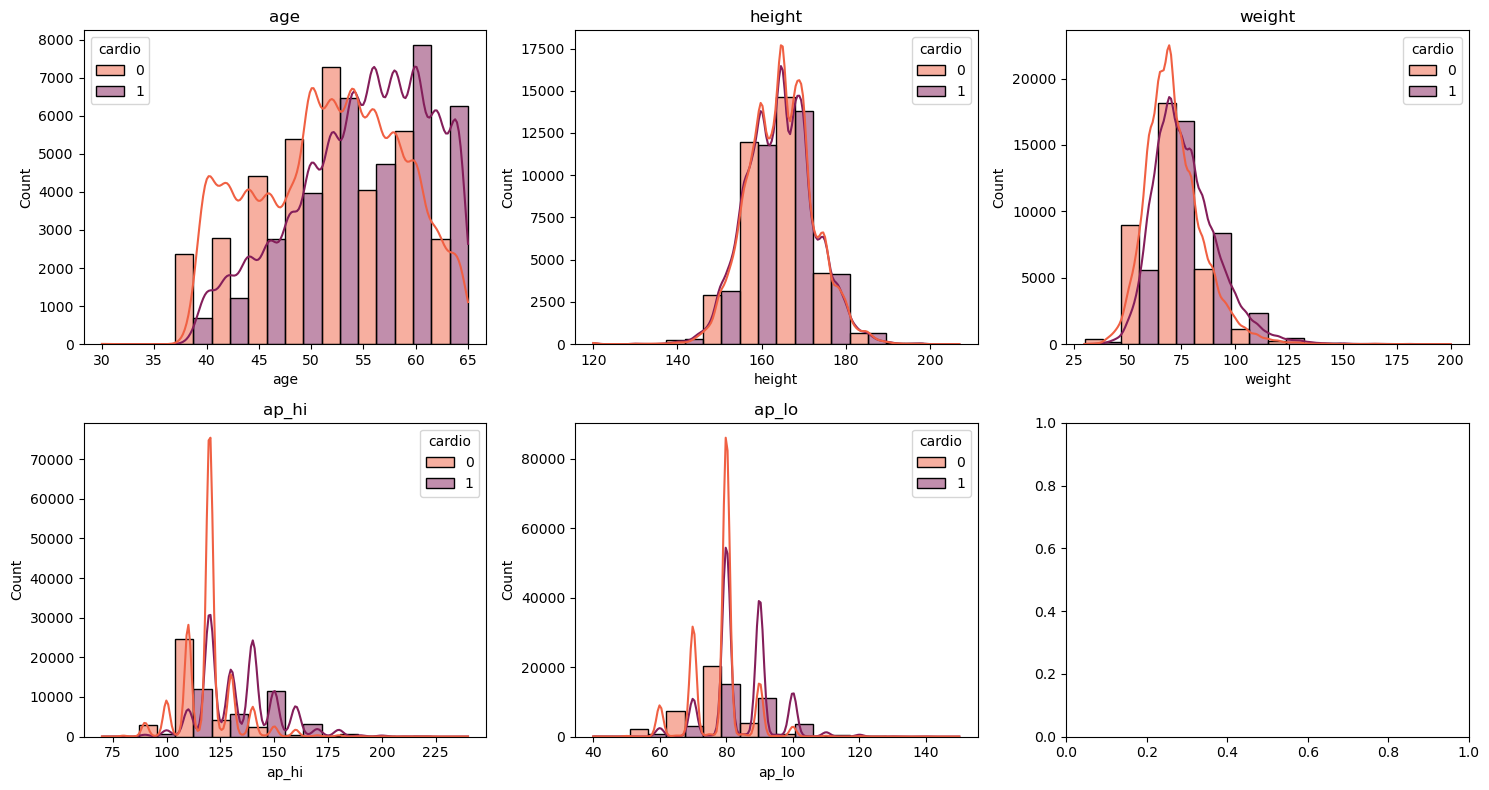

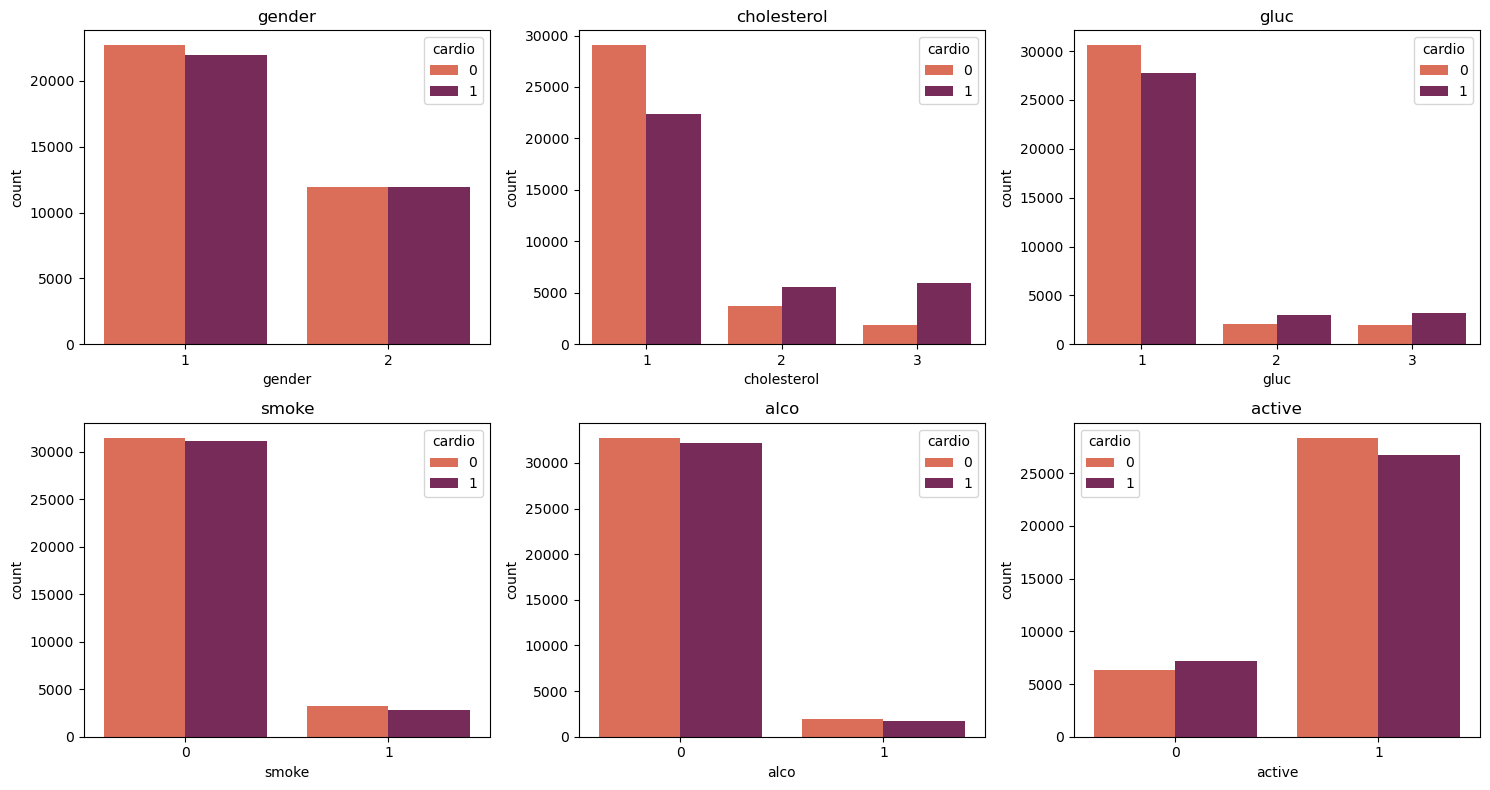

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Columns
num_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]
cat_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

# Set palette
sns.set_palette("rocket_r")

# -------------------------------
# NUMERICAL SUBPLOTS
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="cardio", multiple="dodge", kde=True, bins=10, ax=axes[i], palette="rocket_r")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# -------------------------------
# CATEGORICAL SUBPLOTS
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="cardio", ax=axes[i], palette="rocket_r")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

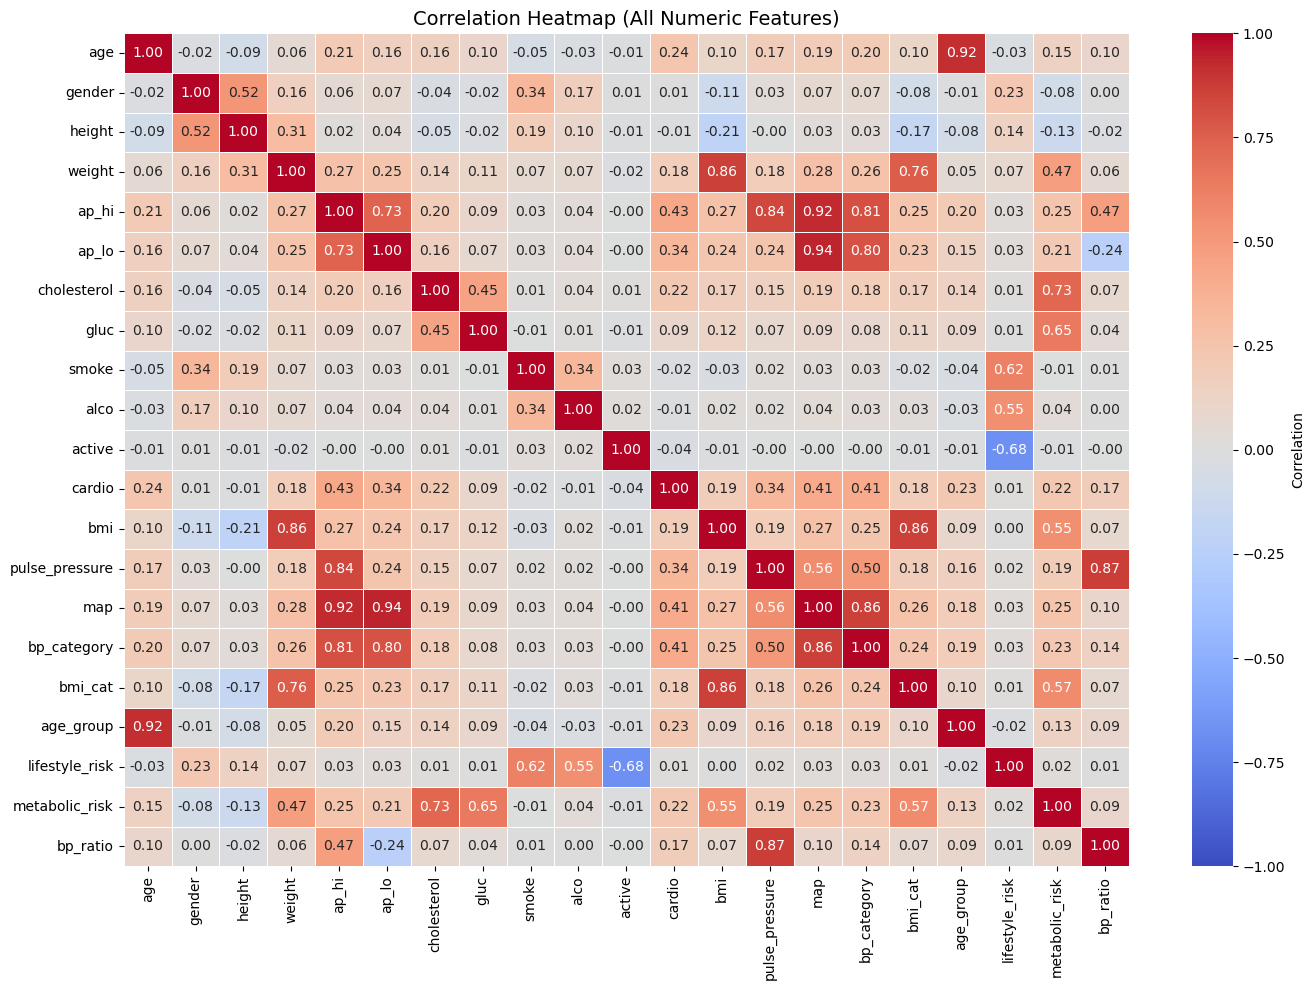

Correlation with cardio target:


,correlation
cardio,1.000000
ap_hi,0.428196
map,0.409928
bp_category,0.409476
ap_lo,0.340837
pulse_pressure,0.336895
age,0.238925
age_group,0.225340
metabolic_risk,0.223324
cholesterol,0.221461


In [24]:
# Correlation heatmap for all numeric features (including target)
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap (All Numeric Features)', fontsize=14)
plt.tight_layout()
plt.show()

# Sorted correlation with target
if 'cardio' in corr_matrix.columns:
    target_corr = corr_matrix['cardio'].sort_values(ascending=False)
    print('Correlation with cardio target:')
    display(target_corr.to_frame('correlation'))

## Feature engineering

In [10]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# ASSUMPTION:
# df is already loaded and cleaned enough to use.
# Example:
# df = pd.read_csv("/content/sample_data/cardio_train.csv", sep=";")
# --------------------------------------------------

# =========================
# 1) BMI
# =========================
# BMI = weight adjusted for height.
# Weight alone is incomplete because 80 kg means different things for a short vs tall person.
# This is a standard obesity proxy and is usually more informative than raw height/weight alone.
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# =========================
# 2) PULSE PRESSURE
# =========================
# Pulse pressure = systolic - diastolic.
# This reflects the gap between top and bottom blood pressure.
# Larger values can indicate arterial stiffness and elevated cardiovascular risk.
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

# =========================
# 3) MEAN ARTERIAL PRESSURE (MAP)
# =========================
# MAP estimates average arterial pressure across the cardiac cycle.
# It is often more clinically meaningful than looking at systolic/diastolic separately.
# Standard approximation: diastolic + 1/3 * pulse pressure
df["map"] = df["ap_lo"] + (df["ap_hi"] - df["ap_lo"]) / 3

# =========================
# 4) BLOOD PRESSURE CATEGORY
# =========================
# Raw BP values are useful, but a clinical category can capture threshold effects.
# Example: 119 and 121 are numerically close, but one may move into a higher risk category.
# This creates a simple ordinal feature:
# 0 = normal
# 1 = elevated
# 2 = hypertensive
def bp_category(row):
    if row["ap_hi"] >= 140 or row["ap_lo"] >= 90:
        return 2
    elif row["ap_hi"] >= 120 or row["ap_lo"] >= 80:
        return 1
    else:
        return 0

df["bp_category"] = df.apply(bp_category, axis=1)

# =========================
# 5) BMI CATEGORY
# =========================
# Cardiovascular risk is not perfectly linear with BMI.
# Turning BMI into categories can help capture the fact that obesity thresholds matter.
# 0 = underweight
# 1 = normal
# 2 = overweight
# 3 = obese
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

df["bmi_cat"] = df["bmi"].apply(bmi_category)

# =========================
# 6) AGE GROUP
# =========================
# Cardiovascular risk usually rises non-linearly with age.
# Age buckets can help models capture this threshold-like effect.
# IMPORTANT:
# This assumes age is already in years.
# If age is still in days, convert first.
df["age_group"] = pd.cut(
    df["age"],
    bins=[30, 40, 50, 60, 70, 100],
    labels=False,
    include_lowest=True
)

# =========================
# 7) LIFESTYLE RISK SCORE
# =========================
# Smoke and alcohol alone often look weak in this dataset.
# But combined unhealthy behaviors may be more informative than isolated indicators.
# active = 1 means physically active, so (1 - active) converts inactivity into a risk point.
# Range:
# 0 = lower lifestyle risk
# 3 = higher lifestyle risk
df["lifestyle_risk"] = df["smoke"] + df["alco"] + (1 - df["active"])

# =========================
# 8) METABOLIC RISK SCORE
# =========================
# This combines several metabolic warning signs into one feature.
# Higher cholesterol, higher glucose, and obesity often cluster together in cardiovascular risk.
# Using a count is simple and interpretable.
# Range:
# 0 to 3
df["metabolic_risk"] = (
    (df["cholesterol"] > 1).astype(int) +
    (df["gluc"] > 1).astype(int) +
    (df["bmi"] > 30).astype(int)
)

# =========================
# 9) BLOOD PRESSURE RATIO
# =========================
# This captures the relationship between systolic and diastolic pressure.
# It is less standard than pulse pressure or MAP, but can still carry signal.
# Add a tiny safeguard if needed to avoid division by zero, though ap_lo should already be cleaned.
df["bp_ratio"] = df["ap_hi"] / df["ap_lo"]

# =========================
# INSPECT NEW FEATURES
# =========================
print("\nNew feature summary:")
print(df[[
    "bmi",
    "pulse_pressure",
    "map",
    "bp_category",
    "bmi_cat",
    "age_group",
    "lifestyle_risk",
    "metabolic_risk",
    "bp_ratio"
]].describe(include="all").T)

df[[
    "bmi",
    "pulse_pressure",
    "map",
    "bp_category",
    "bmi_cat",
    "age_group",
    "lifestyle_risk",
    "metabolic_risk",
    "bp_ratio"
]].head()


New feature summary:
                  count       mean        std        min        25%  \
bmi             68612.0  27.457802   5.257497  10.726644  23.875115   
pulse_pressure  68612.0  45.367632  11.666815   0.000000  40.000000   
map             68612.0  96.424955  11.029512  50.000000  93.333333   
bp_category     68612.0   1.203769   0.663624   0.000000   1.000000   
bmi_cat         68612.0   1.872267   0.807882   0.000000   1.000000   
age_group       68612.0   1.759969   0.754478   0.000000   1.000000   
lifestyle_risk  68612.0   0.338002   0.567472   0.000000   0.000000   
metabolic_risk  68612.0   0.661240   0.849277   0.000000   0.000000   
bp_ratio        68612.0   1.562156   0.149196   1.000000   1.500000   

                      50%         75%         max  
bmi             26.346494   30.119376  108.169847  
pulse_pressure  40.000000   50.000000  140.000000  
map             93.333333  103.333333  173.333333  
bp_category      1.000000    2.000000    2.000000  
bmi_cat

,bmi,pulse_pressure,map,bp_category,bmi_cat,age_group,lifestyle_risk,metabolic_risk,bp_ratio
0,21.967120,30,90.000000,1,1,1,0,0,1.375000
1,34.927679,50,106.666667,2,3,2,0,2,1.555556
2,23.507805,60,90.000000,1,1,2,1,1,1.857143
3,28.710479,50,116.666667,2,2,1,0,0,1.500000
4,23.011177,40,73.333333,0,1,1,1,0,1.666667


## Premodel checks

In [11]:
# Final checks
df = df.drop(columns=['id'], errors='ignore')
print(df.isnull().sum())
df['cardio'].value_counts(normalize=True)

age               0
gender            0
height            0
weight            0
ap_hi             0
ap_lo             0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio            0
bmi               0
pulse_pressure    0
map               0
bp_category       0
bmi_cat           0
age_group         0
lifestyle_risk    0
metabolic_risk    0
bp_ratio          0
dtype: int64


cardio
0    0.505305
1    0.494695
Name: proportion, dtype: float64

In [12]:
num_cols = [
    'age', 'height', 'weight',
    'ap_hi', 'ap_lo',
    'bmi', 'pulse_pressure', 'map', 'bp_ratio'
]

ord_cols = [
    'cholesterol', 'gluc',
    'bp_category', 'bmi_cat', 'age_group'
]

bin_cols = [
    'gender', 'smoke', 'alco', 'active'
]

count_cols = [
    'lifestyle_risk', 'metabolic_risk'
]

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='cardio')
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ord_cols),
        ('bin', 'passthrough', bin_cols),
        ('count', StandardScaler(), count_cols)
    ]
)

In [15]:
# -------------------------
# 6. Fixed heatmap scale for all models
#    Same vmin/vmax lets you compare visually
# -------------------------
HEATMAP_VMIN = 0
HEATMAP_VMAX = len(y_test)

# -------------------------
# 7. Reusable evaluation function
# -------------------------
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    model_accuracy = accuracy_score(y_true, y_pred)
    model_precision = precision_score(y_true, y_pred, zero_division=0)
    model_recall = recall_score(y_true, y_pred, zero_division=0)
    model_f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{model_name} Accuracy : {model_accuracy:.4f}")
    print(f"{model_name} Precision: {model_precision:.4f}")
    print(f"{model_name} Recall   : {model_recall:.4f}")
    print(f"{model_name} F1 Score : {model_f1:.4f}")

    if y_prob is not None:
        model_roc_auc = roc_auc_score(y_true, y_prob)
        print(f"{model_name} ROC-AUC : {model_roc_auc:.4f}")

    model_cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        model_cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        vmin=HEATMAP_VMIN,
        vmax=HEATMAP_VMAX,
        cbar=True,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model_cm

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Base model

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

Logistic Regression Accuracy : 0.7293
Logistic Regression Precision: 0.7570
Logistic Regression Recall   : 0.6668
Logistic Regression F1 Score : 0.7091
Logistic Regression ROC-AUC : 0.7915


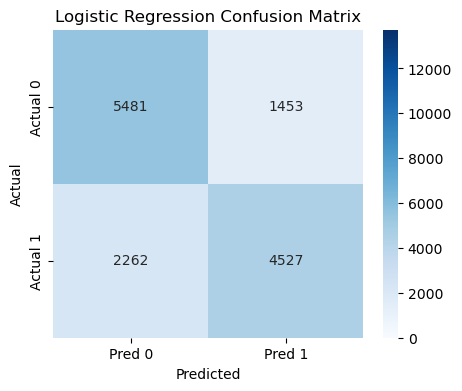

In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)
logistic_roc_auc = roc_auc_score(y_test, logistic_prob)

logistic_cm = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=logistic_pred,
    y_prob=logistic_prob
)

Random Forest Accuracy : 0.7083
Random Forest Precision: 0.7100
Random Forest Recall   : 0.6936
Random Forest F1 Score : 0.7017
Random Forest ROC-AUC : 0.7659


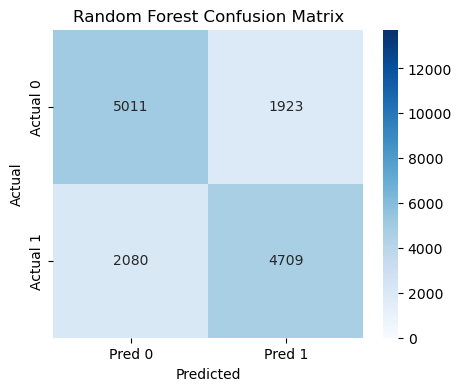

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

rf_cm = evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_pred,
    y_prob=rf_prob
)

Gradient Boosting Accuracy : 0.7369
Gradient Boosting Precision: 0.7603
Gradient Boosting Recall   : 0.6836
Gradient Boosting F1 Score : 0.7199
Gradient Boosting ROC-AUC : 0.8025


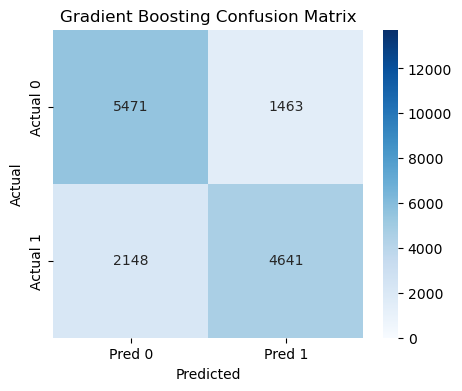

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred, zero_division=0)
gb_recall = recall_score(y_test, gb_pred, zero_division=0)
gb_f1 = f1_score(y_test, gb_pred, zero_division=0)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

gb_cm = evaluate_model(
    model_name="Gradient Boosting",
    y_true=y_test,
    y_pred=gb_pred,
    y_prob=gb_prob
)

XGBoost Accuracy : 0.7353
XGBoost Precision: 0.7585
XGBoost Recall   : 0.6823
XGBoost F1 Score : 0.7184
XGBoost ROC-AUC  : 0.8018


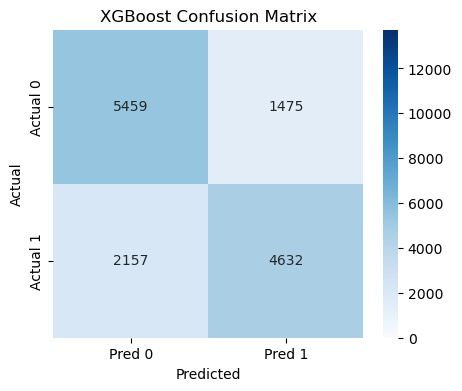

In [21]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print(f"XGBoost Accuracy : {xgb_accuracy:.4f}")
print(f"XGBoost Precision: {xgb_precision:.4f}")
print(f"XGBoost Recall   : {xgb_recall:.4f}")
print(f"XGBoost F1 Score : {xgb_f1:.4f}")
print(f"XGBoost ROC-AUC  : {xgb_roc_auc:.4f}")

xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    vmin=HEATMAP_VMIN,
    vmax=HEATMAP_VMAX,
    cbar=True,
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

[LightGBM] [Info] Number of positive: 27153, number of negative: 27736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1191
[LightGBM] [Info] Number of data points in the train set: 54889, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494689 -> initscore=-0.021244
[LightGBM] [Info] Start training from score -0.021244
LightGBM Accuracy : 0.7363
LightGBM Precision: 0.7576
LightGBM Recall   : 0.6866
LightGBM F1 Score : 0.7203
LightGBM ROC-AUC  : 0.8014


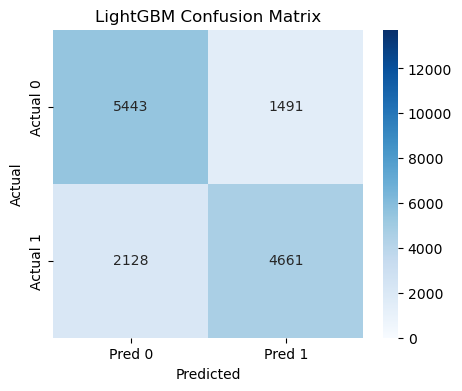

In [22]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

lgbm_model = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, zero_division=0)
lgbm_recall = recall_score(y_test, lgbm_pred, zero_division=0)
lgbm_f1 = f1_score(y_test, lgbm_pred, zero_division=0)
lgbm_roc_auc = roc_auc_score(y_test, lgbm_prob)

print(f"LightGBM Accuracy : {lgbm_accuracy:.4f}")
print(f"LightGBM Precision: {lgbm_precision:.4f}")
print(f"LightGBM Recall   : {lgbm_recall:.4f}")
print(f"LightGBM F1 Score : {lgbm_f1:.4f}")
print(f"LightGBM ROC-AUC  : {lgbm_roc_auc:.4f}")

lgbm_cm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    lgbm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    vmin=HEATMAP_VMIN,
    vmax=HEATMAP_VMAX,
    cbar=True,
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy,
        lgbm_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision,
        gb_precision,
        xgb_precision,
        lgbm_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall,
        gb_recall,
        xgb_recall,
        lgbm_recall
    ],
    'F1 Score': [
        logistic_f1,
        rf_f1,
        gb_f1,
        xgb_f1,
        lgbm_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        xgb_roc_auc,
        lgbm_roc_auc
    ]
})

results_df.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.708300,0.710042,0.693622,0.701736,0.765871
4,LightGBM,0.736282,0.757640,0.686552,0.720346,0.801442
2,Gradient Boosting,0.736865,0.760321,0.683606,0.719926,0.802477
3,XGBoost,0.735335,0.758474,0.682280,0.718362,0.801842
0,Logistic Regression,0.729287,0.757023,0.666814,0.709061,0.791460


Missing a true positive (a patient who actually has cardiovascular disease) is more costly than incorrectly flagging a healthy person, so minimizing false negatives is critical. Precision matters for reducing unnecessary alerts, but in this context, recall-first, then optimize precision using threshold tuning, and use F1 only as a balance metric if you need a single score.

### Save Model as .pkl in /models

In [25]:
# Save best model as a .pkl file in repo/models
from pathlib import Path
import pickle

model_lookup = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

best_row = results_df.sort_values(by=['Recall', 'F1 Score', 'ROC-AUC'], ascending=False).iloc[0]
best_model_name = best_row['Model']
best_model = model_lookup[best_model_name]

project_root = Path.cwd()
if not (project_root / 'dataset').exists() and (project_root.parent / 'dataset').exists():
    project_root = project_root.parent

models_dir = project_root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'cardio_best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Best model selected by Recall/F1/ROC-AUC: {best_model_name}')
print(f'Model saved to: {model_path.resolve()}')

Best model selected by Recall/F1/ROC-AUC: Random Forest
Model saved to: C:\Users\tehre\OneDrive\Desktop\Skills Day 2026\Cardiovascular_Risk_Predictor\models\cardio_best_model.pkl


### SHAP explanation + numeric extraction for case markdown used by report generation

Top SHAP contributors:


,feature,shap_value
4,ap_hi,0.120643
13,map,0.085530
5,ap_lo,0.071229
14,bp_category,0.065955
18,metabolic_risk,0.030662
3,weight,0.029479
11,bmi,0.026263
19,bp_ratio,0.025514
1,gender,-0.012072
12,pulse_pressure,-0.008339


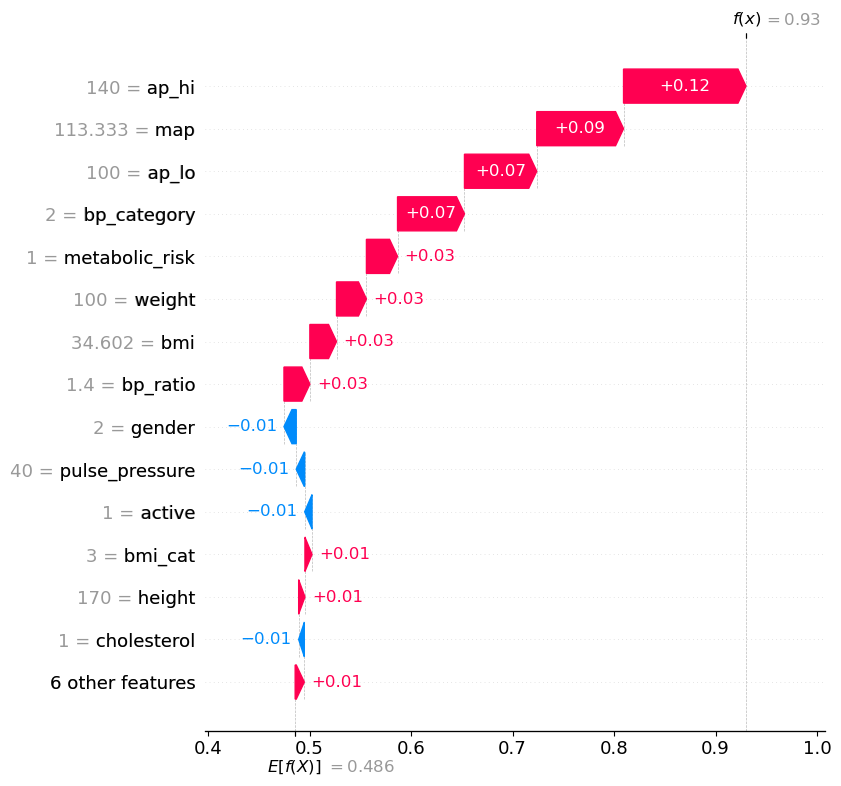

Case markdown with SHAP numeric values saved to: C:\Users\tehre\OneDrive\Desktop\Skills Day 2026\Cardiovascular_Risk_Predictor\reports\case_markdown_from_notebook.md


In [27]:
# SHAP explanation + numeric extraction for case markdown used by report generation
import json
import sys
import subprocess

try:
    import shap
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

# Select one test case to explain
case_index = 0
X_case = X_test.iloc[[case_index]].copy()

# Predict with saved best model object in memory
case_prob = float(best_model.predict_proba(X_case)[0, 1])
case_pred = int(best_model.predict(X_case)[0])
pred_label = 'cardio_disease' if case_pred == 1 else 'no_cardio_disease'

# Build a model-agnostic SHAP explainer
background = X_train.sample(min(200, len(X_train)), random_state=42)
explainer = shap.Explainer(best_model.predict_proba, background)
shap_values = explainer(X_case)

# Extract SHAP values for positive class robustly
values = shap_values.values
if values.ndim == 3:
    class_idx = 1 if values.shape[2] > 1 else 0
    feature_shap = values[0, :, class_idx]

    # Create a single-case SHAP explanation object for waterfall plot
    base_vals = shap_values.base_values
    if hasattr(base_vals, 'ndim') and base_vals.ndim == 2:
        base_value = base_vals[0, class_idx]
    elif hasattr(base_vals, 'ndim') and base_vals.ndim == 1:
        base_value = base_vals[class_idx]
    else:
        base_value = float(base_vals)

    waterfall_exp = shap.Explanation(
        values=feature_shap,
        base_values=base_value,
        data=X_case.iloc[0].values,
        feature_names=X_case.columns.tolist()
    )
elif values.ndim == 2:
    feature_shap = values[0]
    waterfall_exp = shap_values[0]
else:
    raise ValueError(f'Unexpected SHAP values shape: {values.shape}')

shap_df = pd.DataFrame({
    'feature': X_case.columns,
    'shap_value': feature_shap
}).sort_values('shap_value', key=lambda s: s.abs(), ascending=False)

print('Top SHAP contributors:')
display(shap_df.head(15))

# SHAP waterfall plot for one case
shap.plots.waterfall(waterfall_exp, max_display=15)

# Convert SHAP values to numeric dictionary for report-generation markdown
shap_numeric = {
    row['feature']: round(float(row['shap_value']), 6)
    for _, row in shap_df.iterrows()
}

case_features = {
    col: (float(X_case.iloc[0][col]) if pd.api.types.is_number(X_case.iloc[0][col]) else X_case.iloc[0][col])
    for col in X_case.columns
}

case_markdown = f"""# Cardiovascular Case\n\n## Original User Query\nAuto-generated from notebook test case index {case_index}. Replace this line with the original user query when available.\n\n## Extracted Features\n```json\n{json.dumps(case_features, indent=2)}\n```\n\n## Model Prediction\n- Predicted class: {pred_label}\n- Predicted probability: {case_prob:.4f}\n\n## SHAP Values\n```json\n{json.dumps(shap_numeric, indent=2)}\n```\n"""

reports_dir = project_root / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)
case_markdown_path = reports_dir / 'case_markdown_from_notebook.md'
case_markdown_path.write_text(case_markdown, encoding='utf-8')

print(f'Case markdown with SHAP numeric values saved to: {case_markdown_path.resolve()}')